In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from plotting import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

3.9.2


In [2]:
def find_nearest(obj1, obj2):
    #### get dRs
    dR = obj1.deltaR(obj2)
    #### mask where dR to self
    dR = ak.where(dR == 0, None, dR)
    idx = ak.argmin(dR, axis=-1)
    nearest_other = obj2[idx]
    return nearest_other

In [3]:
def sigmoid(x ,L, x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def fit_sigmoid(radii, frac, des_frac=25, string=""):
    print(frac)
    ###initial guess
    if frac[0]>1.:
        frac.insert(0, 0)
        radii.insert(0,0)
    p0 = [max(frac), np.median(np.array(radii)),1]
    popt, pcov = curve_fit(sigmoid, np.array(radii), frac, p0)
    L, x0, k = popt
    if (L/(des_frac-k))-1 > 0:
        x = x0-((1/k)*np.log((L/(des_frac))-1))
        print(f"{string} x value where y = {des_frac}: {x}")
    else:
        print(f"No real solution for y = {des_frac} with sigmoid fit.")
    return popt, pcov
# def plot_cellradius_comp():
def sigmoid_Lfixed(x, x0, k, L=100.0):
    # clip exponent to avoid overflow warnings
    z = np.clip(-k*(x-x0), -700, 700)
    return L / (1.0 + np.exp(z))
def fit_sigmoid_fixedL(radii, fracs, L=100.0, des_frac=25):
    # initial guesses
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
    p0 = [np.median(np.array(radii)),1]

    # bounds: x0 within radii range (with padding), k positive
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = ([np.min(radii) - pad, 1e-6], [np.max(radii) + pad, 10.0])

    popt, pcov = curve_fit(lambda x, x0, k: sigmoid_Lfixed(x, x0, k, L=L),
                           radii, fracs, p0=p0, bounds=bounds)

    x0, k = popt
    return (L, x0, k), pcov
def richards(x, x0, k, nu, L=1.0):
    z = -k*(x-x0)
    return L / (1.0 + np.exp(z))**(1.0/nu)
def fit_richards(radii, fracs, L=1.0):
    x0_guess = np.median(radii)
    k_guess  = 2/np.median(radii)
    nu_guess = 1.0
        # optional: let L float, or fix it to max observed
    if L is None:
        L = fracs.max()
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
   
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = (
        [np.min(radii)-pad, 1e-3, 0.05],   # x0, k, nu
        [np.max(radii)+pad, 10.0/np.median(radii), 20.0]
    )

    popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),
                           radii, fracs, p0=[x0_guess, k_guess, nu_guess], bounds=bounds)
    return (*popt, L), pcov
def richards_x_at_y(y, x0, k, nu, L):
    y = float(y)
    if not (0.0 < y < L) or k == 0 or nu <= 0:
        return np.nan
    arg = (L / y)**nu - 1.0
    if arg <= 0:
        return np.nan
    return x0 - (1.0 / k) * np.log(arg)

In [4]:
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weights.append(np.load(inputpath0+str_R+inputpath1))
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
def fix_weight_length(points, weights, weights_orig):
    if len(weights) < len(weights_orig):
        

In [6]:
##### Load jets
ttbar_jets = ak.from_parquet('/oscar/data/mleblan6/lhay/ttbar_NLO_100k_alljetsV1.parquet')
order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
jets = ttbar_jets[order]

#### load original weights for ttbar, z+jet
N=10000

weights_orig_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_weight_100k.npy")

#### making the ttbar hp dataframes
radii_hp = [5,15,17,18.5,20,22,25,30,100]
ttbar_hp_df = make_df(radii_hp, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_hp_100k/100k_hp_emd_reweight_")
#### print the available fractions
print(ttbar_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = ttbar_hp_df.set_index("fraction")
w_f = df_f.loc[0.71, "weights"]

#### make rest of ttbar dataframes

radii_ps = [1, 15, 18, 24, 25, 30, 50, 100]
ttbar_ps_df = make_df(radii_ps, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_ps_100k/100k_ps_emd_reweight_", "gev_ttbar.npy")

radii_had = [1, 18, 25, 28, 30, 50, 100]
ttbar_had_df = make_df(radii_had, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_had_100k/100k_had_emd_reweight_", "gev_ttbar.npy")

radii_had_10k = [1, 21, 25, 28, 30, 50]
ttbar_had_10k_df = make_df(radii_had_10k, weights_orig_ttbar[0:10000], "/oscar/data/mleblan6/lhay/reweighted_files/10k_ttbar_had/10k_had_emd_reweight_", "gev_ttbar.npy")



[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
(50, 100000)
(50,)


In [7]:
#### make z+jet dfs
radii_z = [5, 7, 10, 12, 15, 18, 20, 25]
zjet_hp_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_")

radii_10k = [5, 7, 10, 12, 15, 18, 20, 25, 30, 150]
zjet_hp_10k_df = make_df(radii_10k, weights_orig_10k, "/oscar/data/mleblan6/rjain/trial1/hp_reweight_0to10k_", "GeV.npy")

radii_z = [5, 9, 10, 12.5, 12.6, 15, 17.2, 20, 25]
zjet_ps_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_", "gev_bigR.npy")
radii_z = [5, 10, 13, 15, 17.2, 20, 25]
zjet_had_df = make_df(radii_z, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_", "gev_bigR.npy")

TTbar hp 100k R for 0.75 RW  25.968
TTBar ps 100k R for 0.75 RW  35.951
TTBar had 100k R for 0.75 RW  35.208
TTbar had 10k R for 0.75 RW  41.389


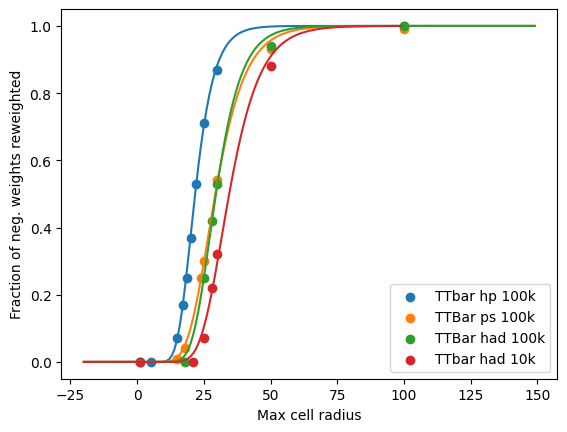

In [81]:
fracs = []
strings = ["TTbar hp 100k", "TTBar ps 100k", "TTBar had 100k","TTbar had 10k"]
weights_orig_list = [weights_orig_ttbar, weights_orig_ttbar, weights_orig_ttbar,  weights_orig_ttbar[0:10000]]
rw_dicts = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df, ttbar_had_10k_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)
    print(f"{strings[i]} R for 0.75 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")

plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

In [82]:
def plot_diff_rw(obs, dfs, strings, fracs, weights_orig, xmin, xmax, nbins, ymin=1e-4, ymax=1e0, obs_str = "", sel=None, title="", raxlim=[0.85, 1.15]):
    if sel is None:
        sel  = np.ones_like(weights_orig, dtype=bool)
    fig, (ax, rax) = plt.subplots(nrows=2,
                        ncols=1,
                        figsize=(8,6),
                        gridspec_kw={"height_ratios": (3, 1)},
                        sharex=True)
    h_orig = hist.Hist(
        hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",),
        storage=hist.storage.Weight(), )
    h_orig.fill(obs, weight = weights_orig[sel])
    h_orig = h_orig/h_orig.sum(flow=False).value
    for i, df in enumerate(dfs):
        weights = np.array(df.loc[df["fraction"]==fracs[i], "weights"].squeeze())[sel]
        h = hist.Hist(
            hist.axis.Regular(nbins,xmin, xmax,name="data",label="reweighted",),
            storage=hist.storage.Weight(), 
        )
        h.fill(obs, weight = weights)
        #### Normalize hists
        h = h/h.sum(flow=False).value
        bin_centers = h.axes[0].centers
        bin_edges = h.axes[0].edges
        ratio, ratio_unc = get_ratio_unc(h, h_orig)
        ratio1, ratio_unc1 = get_ratio_unc(h_orig, h_orig)
        hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')
        hep.histplot(ratio, bins=bin_edges, ax=rax,  color=cmap[i], histtype='step') #yerr = np.sqrt(ratio_unc),
        hep.histplot(h, ax=ax, label = f"{round(fracs[i]*100)}% RW {strings[i]}", color=cmap[i], histtype='step')
        
    hep.histplot(h_orig, ax=ax, label = "Original", color='black')
    rax.set_xlabel(rf"${quantity}$")
    rax.set_ylabel("Reweight/Orig")
    ax.set_title(title)
    ax.set_ylabel(rf"d$\sigma/d{quantity}$")
    ax.set_xlabel(None)
    rax.set_ylim(raxlim[0], raxlim[1])
    ax.set_ylim(ymin, ymax)
    ax.legend()
    ax.set_yscale('log')
    plt.subplots_adjust(hspace=0.05)
    plt.savefig(f"../plots/ttbar_100k/comp_frac_{round(fracs[0], 0)}_{obs_str[0]}.png")
    plt.show()

In [83]:
from plotting import *

[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
[0.   0.01 0.04 0.25 0.3  0.54 0.93 0.99]
[0.   0.   0.25 0.42 0.53 0.94 1.  ]


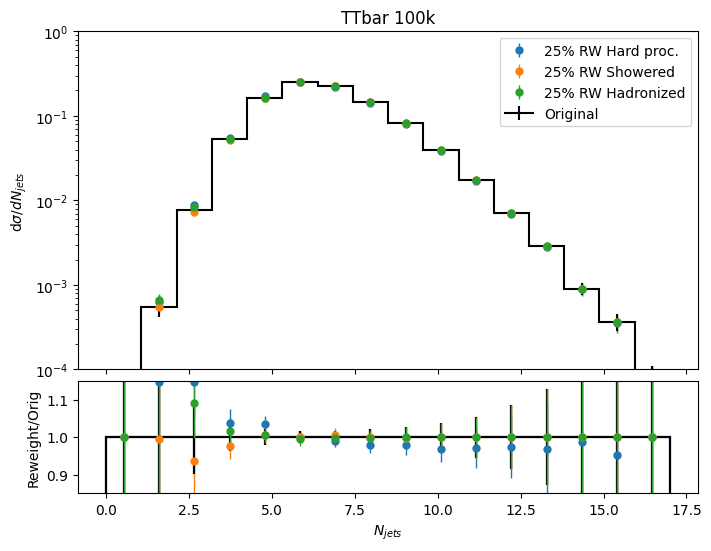

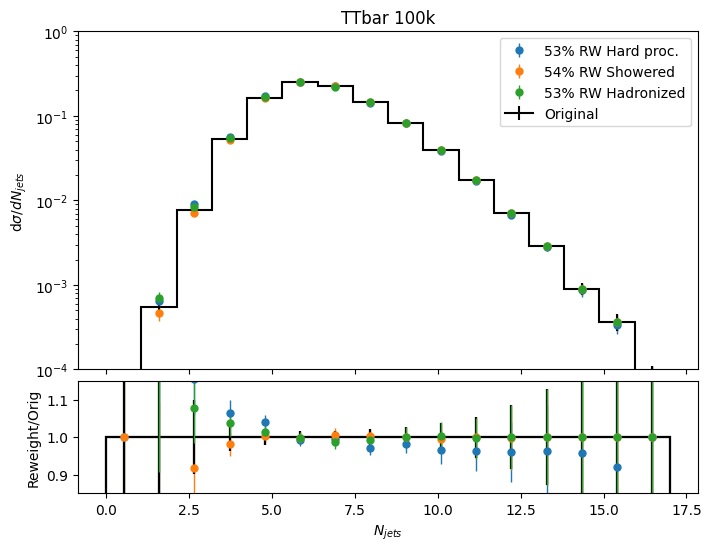

In [86]:
process_str = ["Hard proc.", "Showered", "Hadronized"]
fracs = [0.25, 0.25, 0.25]
print(ttbar_hp_df["fraction"].values)
print(ttbar_ps_df["fraction"].values)
print(ttbar_had_df["fraction"].values)
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
process_str = ["Hard proc.", "Showered", "Hadronized"]
fracs_50 = [0.53, 0.54, 0.53]
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")

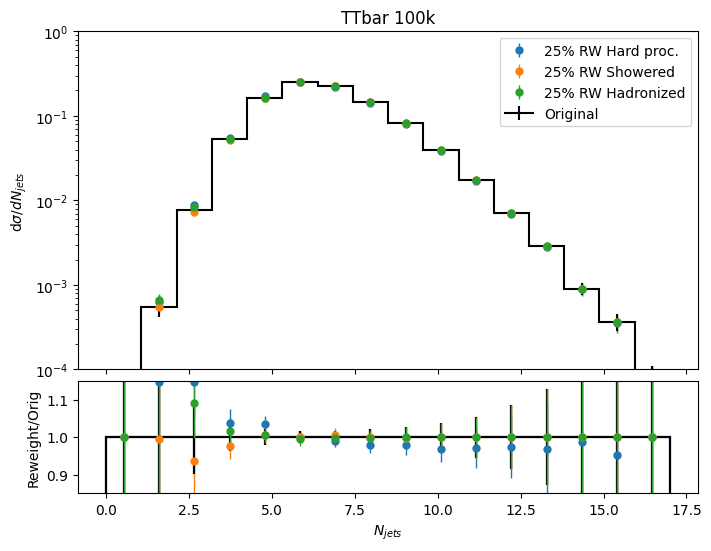

In [87]:
##### dictprocess_str = ["Hard proc.", "Showered", "Hadronized"]
fracs_50 = [0.53, 0.54, 0.53]
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")

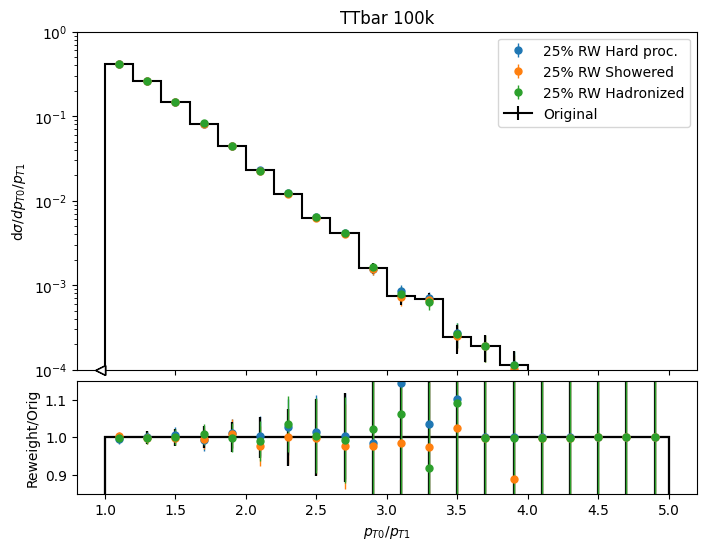

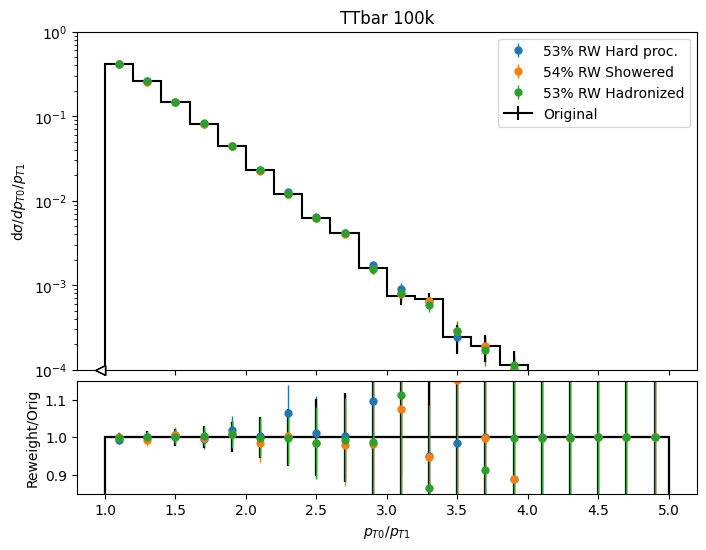

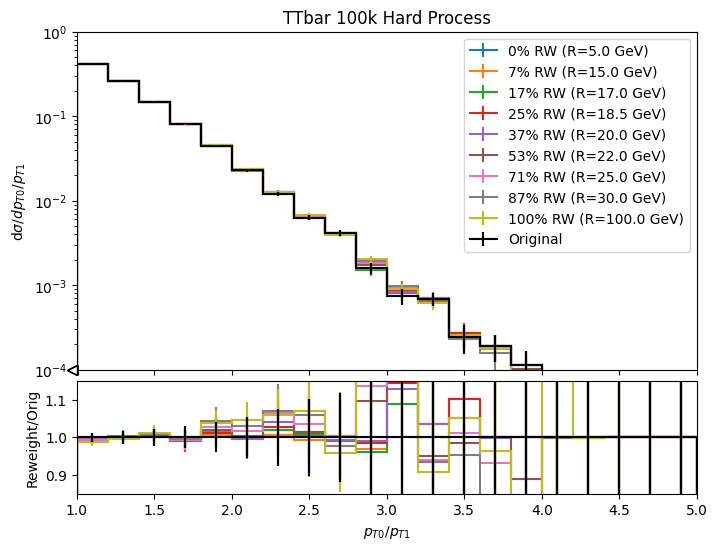

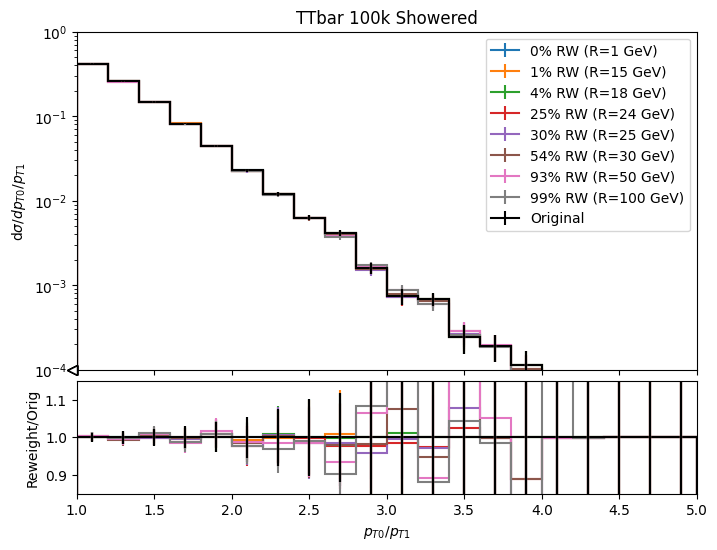

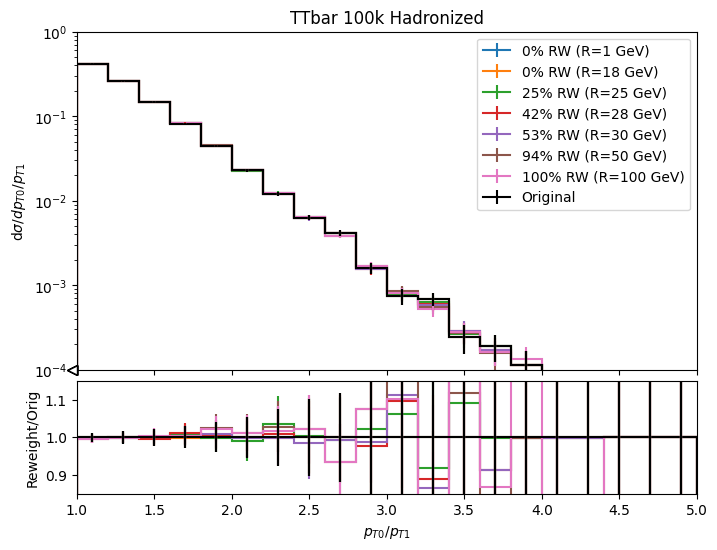

In [88]:
### plot pt ratio of leading and subleading jet
# from plotting import *
obs_str = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin = 1
xmax=5
sel = (ak.num(ttbar_jets.pt, axis=1)>1)
sel_jets = ttbar_jets[sel]
obs = sel_jets.pt[:,-1]/sel_jets.pt[:,-2]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hadronized")

/oscar/home/lhay/cres-distance/cell_reweighting_scripts/plotting.py:98: RuntimeWarning: invalid value encountered in sqrt
  hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black')


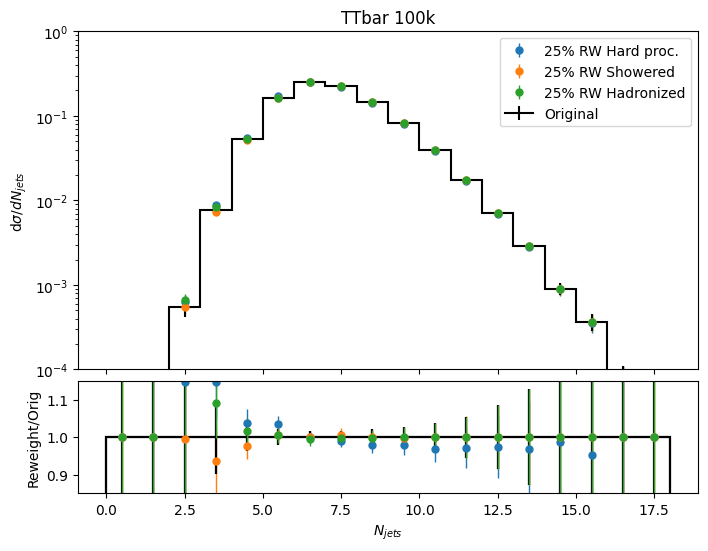

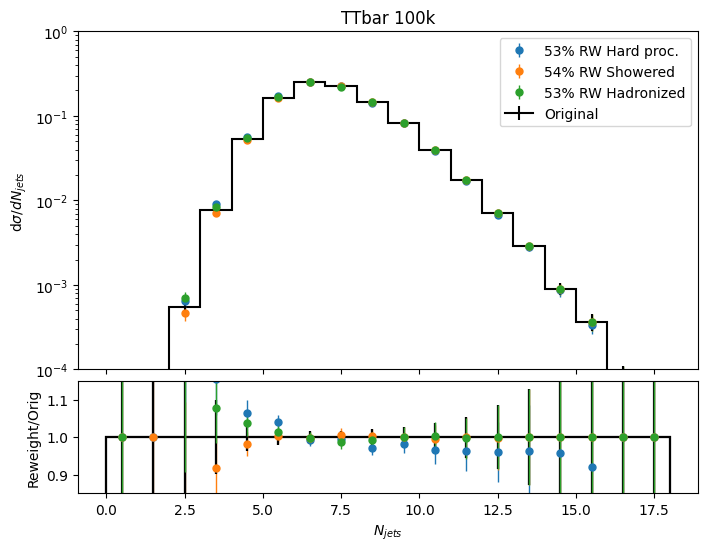

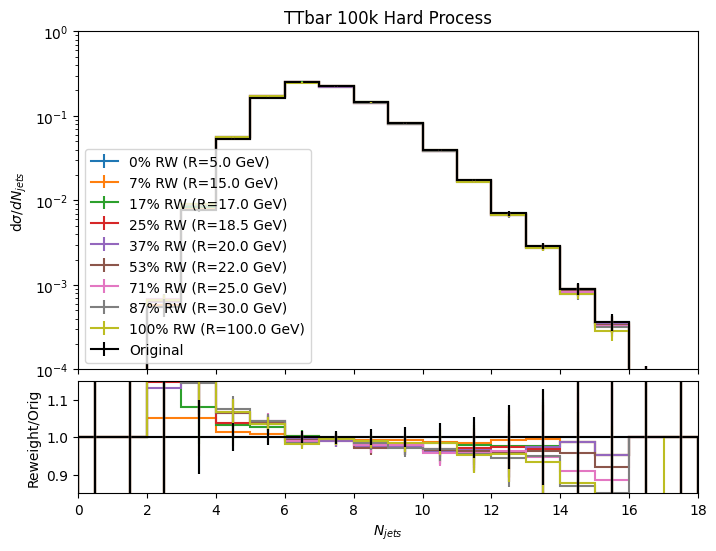

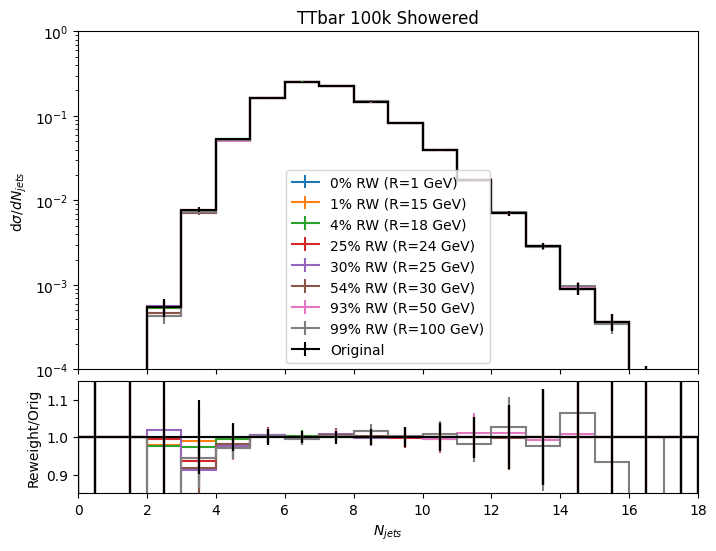

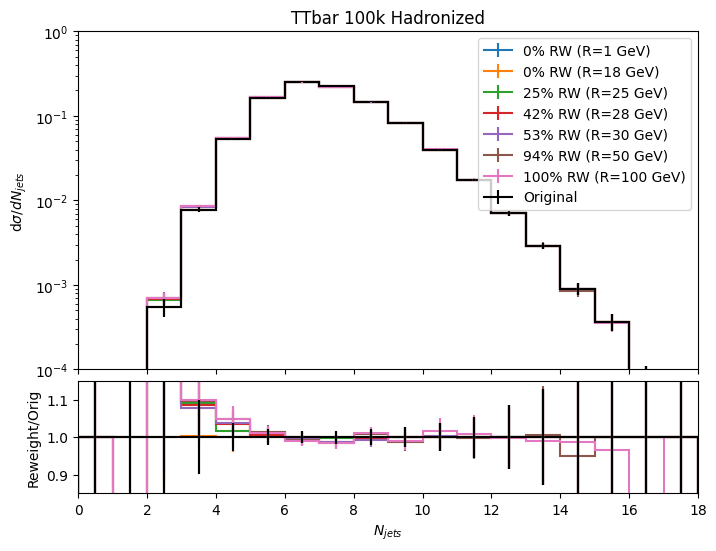

In [89]:
### plot njets
quantity = r'N_{jets}' #string for labels and stuff is the observable
numbins = 18 #number of bins
xmin=0
xmax=18
njets = ak.num(jets.pt, axis=1)
plot_diff_rw(njets, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(njets, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(njets, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(njets, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(njets, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

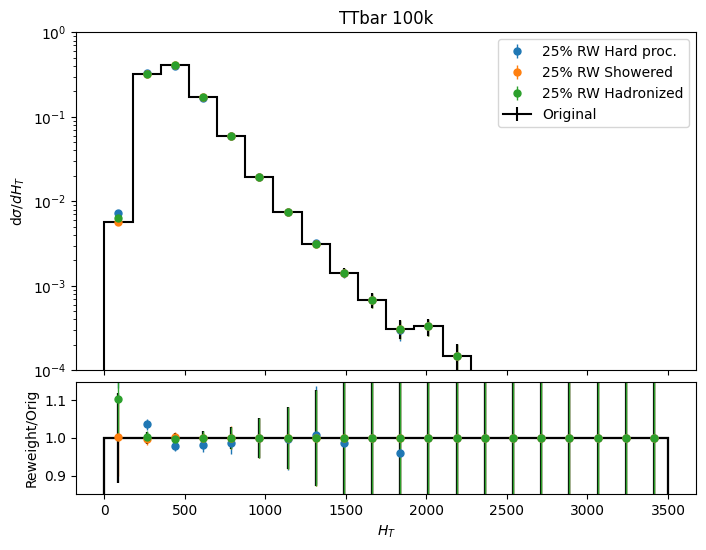

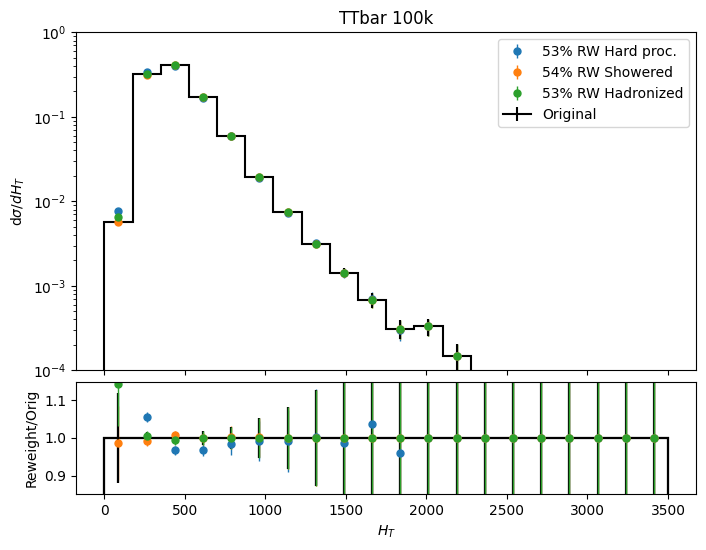

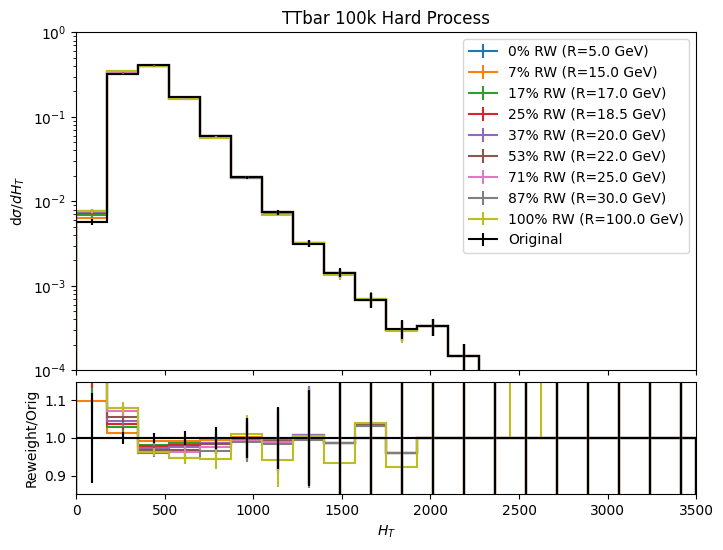

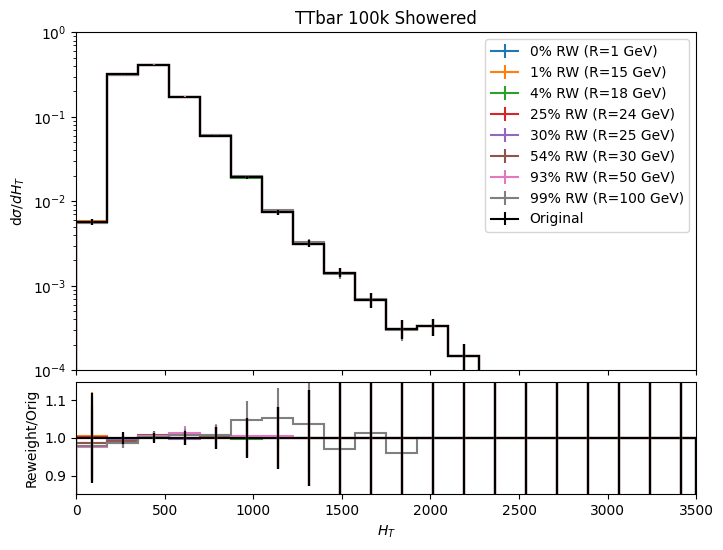

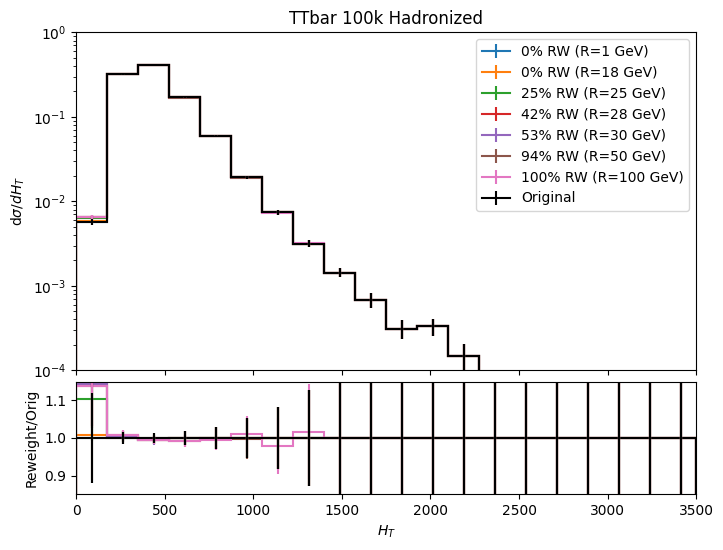

In [90]:
### plot njets
quantity = 'H_T' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=0
xmax=3500
ht = ak.sum(ttbar_jets.pt, axis=-1)
plot_diff_rw(ht, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(ht, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(ht, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(ht, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(ht, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

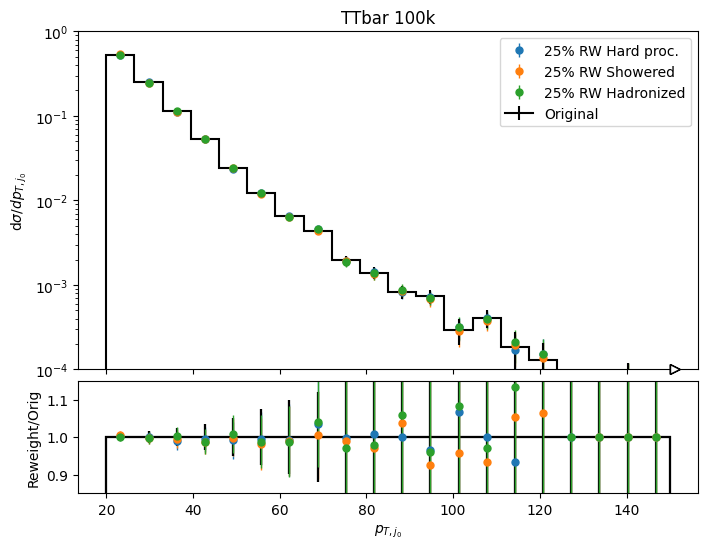

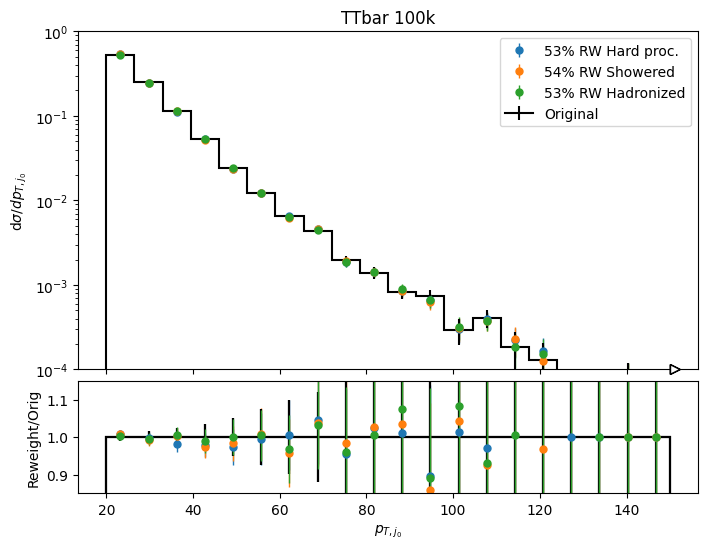

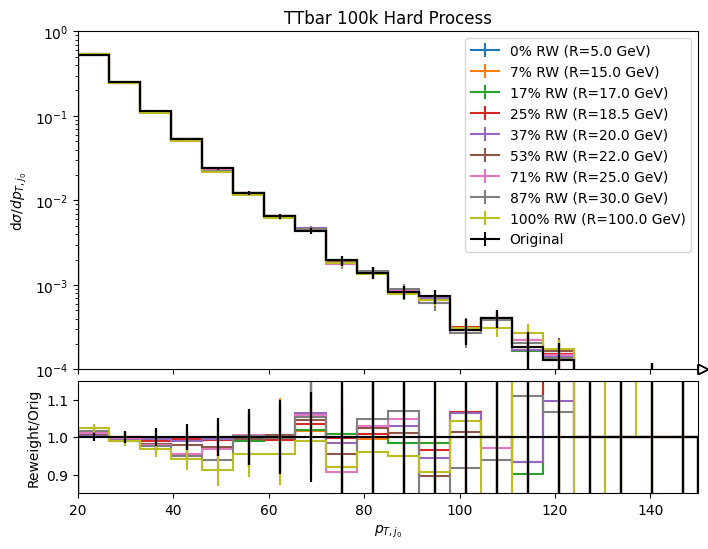

In [ ]:
### plot njets
quantity = 'p_{T,j_0}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=20
xmax=150
pt0 = ttbar_jets.pt[:,0]
plot_diff_rw(pt0, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(pt0, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(pt0, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(pt0, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(pt0, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity = "\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
obs= np.sqrt((sel_jets.eta[:,-1] - sel_jets.eta[:,-2])**2 + (sel_jets.phi[:,-1] - sel_jets.phi[:,-2])**2)
print(len(obs))
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
print(len(mtt))
print(np.sum(sel))
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")